<div style="text-align: center; padding-top: 12%;">

# Confidence Intervals and Applications to Reinforcement Learning

## DATA 301 @ WM

</div>

## <font color='blue'> Introduction to RL</font>

Reinforcement Learning is a type of machine learning where **an agent learns to make decisions by performing actions in an environment to maximize some notion of cumulative reward**.

Unlike supervised learning, where the model learns from a dataset of **labeled examples**, RL learns from the `consequences of its actions`, using feedback from the environment to learn optimal behaviors over time.


### Reference:

<figure class = "fragment fade-up">
<center>
<img  class = “no-fragment" src='https://m.media-amazon.com/images/I/81qAc-ghXrL._SY522_.jpg'width='300px'/>
<figcaption><a href="https://www.amazon.com/Reinforcement-Learning-Introduction-Adaptive-Computation/dp/0262039249/ref=sr_1_2?crid=EP0RD0JHFNNN&keywords=barto+sutton&qid=1695067234&sprefix=barto+sutton%2Caps%2C94&sr=8-2&ufe=app_do%3Aamzn1.fos.18ed3cb5-28d5-4975-8bc7-93deae8f9840" target="_blank">Reinforcement Learning - An Introduction</a></figcaption> </td></center>
</figure>


### How Can A Robot Learn?
If we would like to design a robot or a machine that makes autonomous decisions how can we possibly achieve that?

<figure>
<center>
<img src='https://dataaspirant.com/wp-content/uploads/2023/03/5-16.png'/>
    </center>
</figure>

### A Markov Decision Process Framework
**The Challenge**: There are so many choices to be made (paths, courses of action, etc.), so which one is worth pursuing and how the machine can be programmed to start learning how to make good choices?

One possible answer is to consider a **Markov Decision Process framework (MDP)**.

<figure class = "fragment fade-up">
<center>
<img class = “no-fragment" 
                          src='https://i.imgur.com/vOAGlLB.png'width='600px' />
<figcaption>The agent-environment interaction in a Markov decision process.</figcaption></center>
</figure>

The learner and decision maker is called the *agent*. The thing it interacts with, comprising everything outside the agent, is called the *environment*.

#### <font color='blue'> Key Concepts </font>

1. **Agent**: The learner or decision-maker.
2. **Environment**: Everything the agent interacts with. It provides feedback to the agent in the form of rewards.
3. **State**: A representation of the current situation or configuration of the environment.
4. **Action**: The set of all possible moves the agent can make.
5. **Reward**: Feedback from the environment to evaluate the action taken by the agent.
6. **Policy ($\pi$)**: A strategy used by the agent to determine the next action based on the current state.
7. **Value Function ($V^{\pi}(s)$)**: A function that estimates the expected **cumulative reward** from a given state following the policy.
8. **Q-Value (Action-Value $Q^{\pi}(s,a)$)**: A function that estimates the expected **cumulative reward** for taking a specific action in a given state and following a certain policy thereafter.

#### Trajectory
<figure class = "fragment fade-up">
<center>
<img class = "no-fragment" src='https://i.imgur.com/vOAGlLB.png'width='200px' />
<figcaption>The agent-environment interaction in a Markov decision process.</figcaption></center>
</figure>
                          
The MDP and agent together give rise to a sequence or trajectory in time, such as:
$S_0,A_0,R_1,S_1,A_1,R_2,S_2,A_2,R_3,\dots,S_t,A_t,R_{t},\dots$
- In a finite MDP, the sets of states, actions, and rewards $\left(S, A, \text{and}\, R\right)$ all have a finite number of elements. In this case, the random variables $R_t$ and $S_t$ have well defined discrete probability distributions dependent only on the preceding state and action.
- If a state includes information about all aspects of the **past agent-environment interaction that make a difference for the future**, then the state is said to have the *Markov property.*

### <font color='blue'> Example: An N-Armed Bandit Problem </font>

![image](https://blogs.mathworks.com/images/loren/2016/multiarmedbandit.jpg)
- Suppose you have to choose among k different options or actions repeatedly.
- After each choice, you receive a numerical reward from a stationary probability distribution that depends on your selected action.
- Your objective is to maximize the expected total reward over some time, for example, over many action selections or time steps.

The setup can also be seen as a casino game problem. Suppose you have to choose among k different options or actions repeatedly. After each choice, you receive a numerical reward from a stationary probability distribution that depends on your selected action. Your objective is to maximize the expected total reward over some time, for example, over many action selections or time steps.

We want to determine the values of actions and use these estimates to make action selection decisions.

#### A Simple Estimation
A natural way to estimate this is by averaging the rewards actually received:

$$Q_t(a)\overset{\Delta}{=}\frac{\text{sum of rewards when}\,a\,\text{taken prior to}\,t}{\text{number of times}\,a\,\text{taken prior to}\,t}=\frac{\displaystyle\sum\limits_{i=1}^{t-1}R_i\cdot \mathbb{1}_{A_i=a}}{\displaystyle\sum\limits_{i=1}^{t-1}\mathbb{1}_{A_i=a}}$$

#### The *Greedy* Action Selection
Defined as
$$A_t\overset{\Delta}{=}\underset{a}{\text{argmax}}Q_t(a)$$
- Always exploits current knowledge to maximize immediate reward
- Straightforward alternative: behave greedily most of the time, but explore with small probability $\epsilon$: $\epsilon$-greedy method

<figure  class = "fragment fade-up">
<center>
<img  class = "no-fragment" src='https://i.imgur.com/039uIEI.png'width='600px'/>
<figcaption>Pseudo-Code for an $\epsilon$-greedy method</figcaption></center>
</figure>

#### Critical Thinking
1. How can we code the $\epsilon$-greedy method?
1. How to simulate an environment to test it?
1. Can the $\epsilon$-greedy method be improved?

Greedy action selection always exploits current knowledge to maximize immediate reward; it spends no time at all sampling apparently inferior actions to see if they might really be better. A simple alternative is to behave greedily most of the time, but every once in a while, say with small probability $\epsilon$, instead select randomly from among all the actions with equal probability, independently of the action-value estimates. We call methods using this near-greedy action selection rule $\epsilon$-greedy methods.

## <font color='blue'> Central Limit Theorem </font>

If X is a random variable and we consider the sampling of X with sample sizes greater than 30 then the distribution of the sample means is almost normally distributed.

$$\text{If the sample size }n\,\, \text{increases, then } \bar{X}\sim  N\left(\mu_X,\frac{\sigma_X}{\sqrt{n}}\right)$$
where $\bar{x}$ represents the sample mean.

<font color='red'>**Big Idea:**</font> the random variable X may follow some **unknown** distribution however, if we consider sampling from X with sample sizes that are big, then the distribution of the corresponfing sample means is almost normal.

<font color='red'>**Recommended Instructional Video:**</font> https://www.youtube.com/watch?v=oPQ4mNcqY7k&t=304

### The Meaning of CLT in Probability

$$\large \text{P}\left(\left|\bar{X}-\mu\right|<d\right)>1-\alpha$$
- $ \left|\bar{X}-\mu\right|<d $ means $ \bar{X}-d<\mu<\bar{X}+d$
- $1-\alpha$ is the confidence level (e.g., for a 95% confidence level, $1-\alpha=0.95$)

We call this distance $d$ **margin of error** and from CLT we have that
- $Z\sim N(0,1)$ and $P(-1.96<Z<1.96)=0.95$
- Substitute Z to get $P(-1.96<\frac{\bar{X}-\mu}{\sigma/\sqrt{n}}<1.96)\sim 0.95$
- $d:= z_{\alpha/2}\frac{\sigma}{\sqrt{n}}$ where 
    - $z_{\alpha/2}=1.96$ means how many standard errors we need to cover the desired confidence level and 
    - $\sigma/\sqrt{n}$ means how much sample means typically fluctuate

### Confidence Intervals

The idea is to "**trap**" the value of a population mean inside an interval built around a sample mean, for example:


<figure  class = "fragment fade-up">
<center>
<img  class = "no-fragment" src='https://i.imgur.com/0jxIyTO.png'width='500px'/>
<figcaption>Example of Confidence Intervals</figcaption></center>
</figure>

In the picture above we had an intuitive replresentation of this fact, the true value of the mean is "trapped" inside most of the confidence intervals constructed around sample means from different simple random samples drawn from the same population.
- Black vertical line never moves—the true population parameter is fixed.
- Horizon lines move because our samples are random. A 95% CI procedure is designed so that **about 95 out of every 100** of these intervals cross that black line.

A more detailed picture representing this idea is the following, showing how a 95% confidence interval is working for estimating a population proportion:

### Confidence Intervals with Unknown Variance
The problem is that in real applications, we usually don't know $\sigma$. We only have the sample, so we calculate the sample standard deviation $S$.

Confidence intervals for a population mean:
$\large [\bar{X}-E,\bar{X}+E]$
- $\large E:= t_{\alpha/2, n-1}\cdot\frac{S}{\sqrt{n}}$
- The $t$-distribution has heavier tails than the standard normal distribution because $s$ itself is uncertain
- As $n$ becomes large, $t_{n-1}\rightarrow N(0,1)$

<figure  class = "fragment fade-up">
<center>
<img  class = "no-fragment" src='https://i.imgur.com/ghj5JJx.png'width='400px'/>
<figcaption>Confidence Intervals</figcaption></center>
</figure>


The true $p$ is fixed, but every random sample gives us a different $\hat p$. Most $\hat p$'s—about 95%—land within 1.96 standard errors of $p$. When that happens, if we draw an interval 1.96 standard errors around $\hat p$, the interval reaches back and captures $p$. Occasionally, like $\hat p_2$, our sample estimate is unusually far away, and its confidence interval misses $p$.

## <font color='blue'>Chernoff Bounds and Concentration Inequalities</font>

Chernoff bounds help us quantify **how unlikely it is for an observed result to deviate substantially from its expected value**.

The key intuition is:

> **As we collect more independent observations, large deviations from the expected value become exponentially less likely.**

### Bernoulli Case: Chernoff Bound

Suppose $X_1,\ldots,X_n$ are independent Bernoulli random variables:

$$
X_i =
\begin{cases}
1, & \text{with probability } p_i,\\
0, & \text{with probability } 1-p_i.
\end{cases}
$$

Let the total number of successes be
$
X=\sum_{i=1}^{n}X_i,
$
with expected value
$
\mu=\mathbb{E}[X]=\sum_{i=1}^{n}p_i.
$

Chernoff bounds tell us how unlikely it is for $X$ to be much larger or smaller than its expected value $\mu$. For $\delta>0$:
- **Upper tail:**
$
P(X\geq(1+\delta)\mu)
\leq
e^{-\frac{\delta^2}{2+\delta}\mu}
$
- **Lower tail:**
$
P(X\leq(1-\delta)\mu)
\leq
e^{-\frac{\mu\delta^2}{2}}
$

These bounds decrease exponentially as the number of observations increases.

> **More observations $\Rightarrow$ less uncertainty about the expected outcome.**

### General Case: Hoeffding's Inequality

A closely related concentration inequality, **Hoeffding's inequality**, applies to independent random variables that are not necessarily Bernoulli.

Suppose
$
X_1,\ldots,X_n
$
are independent and bounded:
$
a\leq X_i\leq b.
$

Define the sample average
$
\bar X=\frac{1}{n}\sum_{i=1}^{n}X_i
$
and its expected value
$
\mu=\mathbb{E}[\bar X].
$

Then, for any $t>0$,
$
P(|\bar X-\mu|>t)
\leq
2e^{-\frac{2nt^2}{(b-a)^2}}.
$

This tells us that the probability that the observed sample mean differs
from its expected value by more than $t$ decreases **exponentially with
the number of observations $n$**.

### From Concentration Bounds to a Confidence Radius

- Suppose we want
$
P(|\bar X-\mu|>t)\leq\alpha.
$
- Using Hoeffding's inequality,
$
2e^{-\frac{2nt^2}{(b-a)^2}}\leq\alpha.
$
- Solving for $t$ gives
$
t =
(b-a)
\sqrt{\frac{\ln(2/\alpha)}{2n}}.
$
- Therefore, with probability at least $1-\alpha$,
$
|\bar X-\mu|\leq
(b-a)\sqrt{\frac{\ln(2/\alpha)}{2n}}.
$
- Equivalently, we obtain a confidence bound of the form
$
\mu
\in
\left[
\bar X-
(b-a)\sqrt{\frac{\ln(2/\alpha)}{2n}},
\;
\bar X+
(b-a)\sqrt{\frac{\ln(2/\alpha)}{2n}}
\right].
$
- The most important relationship is
$
\boxed{
\text{uncertainty}
\propto
\frac{1}{\sqrt{n}}
}
$

> So actions that have been tried fewer times have larger uncertainty.

## <font color='blue'>From Confidence Bounds to Multi-Armed Bandits</font>

Imagine several slot machines (or **arms**), each with an unknown expected reward.

For machine $i$:
- $\bar X_i$: observed average reward
- $n_i$: number of times machine $i$ has been played
- $\mu_i$: unknown true expected reward

If $n_i$ is small, we have greater uncertainty about $\mu_i$.
If $n_i$ is large, our estimate $\bar X_i$ becomes more reliable.
This creates a fundamental trade-off:
- **Exploitation:** choose the machine with the highest observed average reward.
- **Exploration:** try machines with greater uncertainty because they might actually be better.

### <font color='blue'>Upper Confidence Bound (UCB) Action Selection</font>

UCB combines these two ideas by assigning each machine an optimistic
estimate of its potential reward:
$
{
UCB_i =
\bar X_i
+
c\sqrt{\frac{\ln k}{n_i}}
}
$
- $\bar X_i$ is the observed average reward of machine $i$,
- $n_i$ is the number of times machine $i$ has been played,
- $k$ is the total number of plays across all machines,
- $c$ controls the amount of exploration.

The two terms have different roles:
$
\underbrace{\bar X_i}_{\text{exploitation}}
+
\underbrace{
c\sqrt{\frac{\ln k}{n_i}}
}_{\text{exploration / uncertainty}}
$
- A machine with a high observed reward has a high UCB because of
**exploitation**.
- A machine that has been tried only a few times also has a high UCB because
$n_i$ is small, making its **uncertainty bonus** large.

### UCB Principle
As a machine is played more often,

$$
n_i\uparrow
\quad\Rightarrow\quad
\sqrt{\frac{\ln k}{n_i}}\downarrow,
$$

so uncertainty about that machine gradually decreases.

> **UCB principle:** Choose the action with the highest plausible reward,
> not necessarily the action with the highest observed reward.

Thus, concentration inequalities provide the mathematical foundation for
balancing **exploration and exploitation** in multi-armed bandit problems.

## Revisit Our Learning Pathway

- **Motivation:** Can robots learn how to make good decisions from experience?
- **MDP:** A mathematical framework for sequential decision-making
- **N-Armed Bandit:** A simplified RL problem for learning action values
- **Greedy:** Always exploit the action that currently looks best
- **$\epsilon$-Greedy:** Add random exploration to discover potentially better actions
- **CLT & Confidence Intervals:** Quantify uncertainty in our estimated rewards
- **Chernoff Bounds:** Bound uncertainty without assuming normally distributed rewards
- **UCB:** Use uncertainty to guide exploration intelligently rather than randomly

**Q**: Why we use Chernoff Bounds for UCB instead of confidence interval from CLT?
> Chernoff Bounds provide **finite-sample guarantees**, even when an action has been tried only a few times. CLT-based confidence intervals rely on a large-sample approximation, which may be unreliable during early exploration.

## <font color='blue'> Code Applications </font>
---

In [1]:
import numpy as np
import random
from scipy.stats import norm, beta, triang, uniform

%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML

### Generate Machines

#### Use Distribution to Simulate the Machine Return

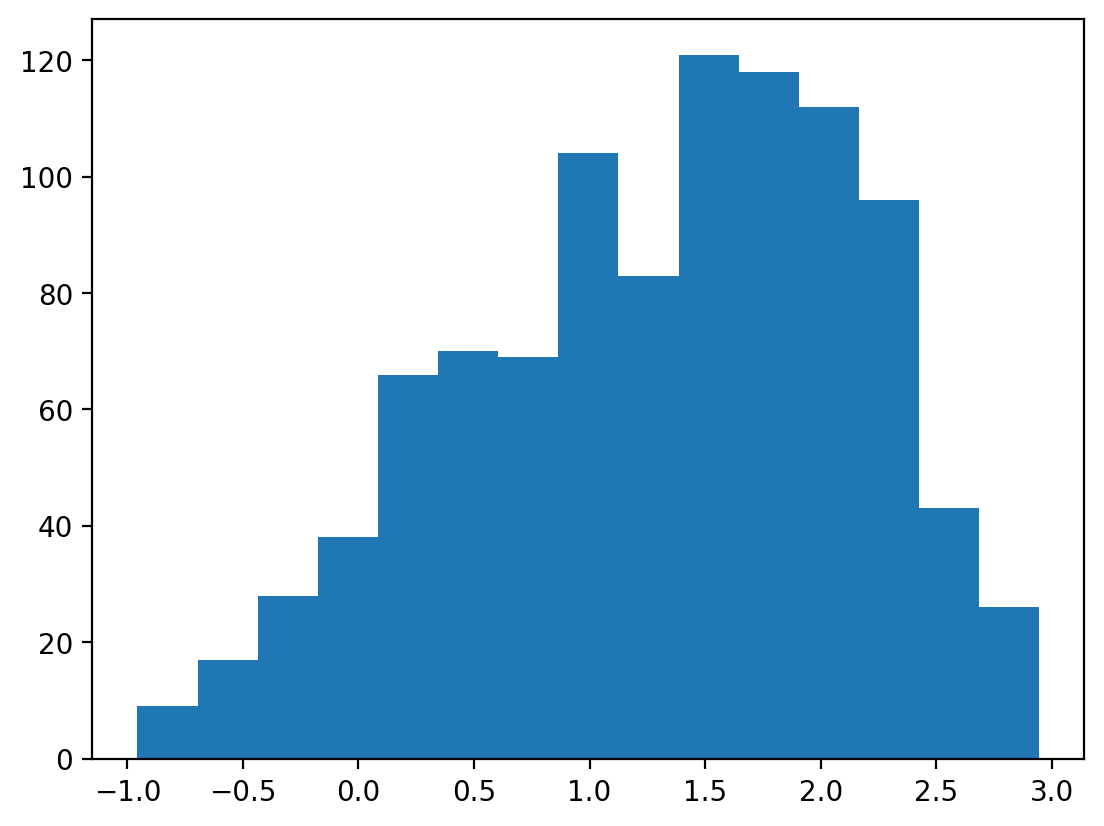

In [2]:
# this is how we generate a slot machine
# we describe the distrubution of rewards
# this is a secret to the player, it is only known by the casino owner
rewards = triang.rvs(size=1000,loc=-1,scale=4,c=0.7)
plt.hist(rewards,bins=15)
plt.show()

The triangular distribution can be represented with an up-sloping line from loc to $(loc + c\cdot scale)$ and then downsloping for $(loc + c\cdot scale)$ to $(loc + scale).$

#### Define Multiple Machines

In [3]:
# We define the machines and their rewards
def Casino(machine): # here we make a Casino with many slot machines

    if(machine == 1):
        return round(norm.rvs(loc=0,scale=1),2)

    if(machine == 2):
        return round(uniform.rvs(loc=0.1,scale=1),2)

    if(machine>=3 and machine <=10):
        return round(triang.rvs(loc=0,scale=1,c=0.5),2)

    if(machine >=11 and machine <=14):
        return round(triang.rvs(loc=0.5,scale=1,c=0.5),2)

    if(machine == 15): # this is the lucky one
        return round(triang.rvs(loc=0.8,scale=3.2,c=1/16),2)

    if(machine >= 16 and machine <= 20):
        return round(uniform.rvs(0,scale=1.25),2)

    if(machine >20):
        print("There are only 20 slot machines!")


In [4]:
# We define the machines and their rewards
def Casino2(machine): # here we make a Casino with many slot machines

    if(machine == 1):
        return round(triang.rvs(loc=0.8,scale=3.2,c=1/16),2) # the lucky one

    if(machine == 2):
        return round(uniform.rvs(loc=0.1,scale=1),2)

    if(machine>=3 and machine <=10):
        return round(triang.rvs(loc=0,scale=1,c=0.5),2)

    if(machine >=11 and machine <=14):
        return round(triang.rvs(loc=0.5,scale=1,c=0.5),2)

    if(machine == 15):
        return round(norm.rvs(loc=0,scale=1),2)

    if(machine >= 16 and machine <= 20):
        return round(uniform.rvs(0,scale=1.25),2)

    if(machine >20):
        print("There are only 20 slot machines!")

In [5]:
Casino(4)

0.35

In [6]:
Casino2(2)

0.73

#### What if we play just one machine such as machine no. 1

Assume the cost for each play is always $1

In [7]:
cash = 25
spin = 1
while(cash>1):
    print("Spin: " + str(spin))
    winnings = Casino(machine=1)
    print("I got " + str(winnings))
    cash = (cash-1) + winnings
    print("I now have $" + str(cash))
    spin = spin +1

Spin: 1
I got -0.16
I now have $23.84
Spin: 2
I got 1.89
I now have $24.73
Spin: 3
I got -1.66
I now have $22.07
Spin: 4
I got 0.75
I now have $21.82
Spin: 5
I got 1.58
I now have $22.4
Spin: 6
I got -0.39
I now have $21.009999999999998
Spin: 7
I got 1.25
I now have $21.259999999999998
Spin: 8
I got -0.8
I now have $19.459999999999997
Spin: 9
I got 1.18
I now have $19.639999999999997
Spin: 10
I got 2.0
I now have $20.639999999999997
Spin: 11
I got 1.74
I now have $21.379999999999995
Spin: 12
I got 0.04
I now have $20.419999999999995
Spin: 13
I got 0.39
I now have $19.809999999999995
Spin: 14
I got 1.67
I now have $20.479999999999997
Spin: 15
I got 2.11
I now have $21.589999999999996
Spin: 16
I got 1.45
I now have $22.039999999999996
Spin: 17
I got 0.17
I now have $21.209999999999997
Spin: 18
I got -0.84
I now have $19.369999999999997
Spin: 19
I got -0.15
I now have $18.22
Spin: 20
I got 1.26
I now have $18.48
Spin: 21
I got -0.31
I now have $17.17
Spin: 22
I got 0.77
I now have $16.94


#### What happens if we play with totally random choices

In [8]:
# this is playing all machines by random choices
N = 500 # the total number of times to play
d = 20 # the number of machines
# tracker variables
machine_record = []
award_record = []
balance = 200.0
for n in range(N):
    machine_choice = np.random.randint(1,d+1) # we choose a random machine each time
    machine_record.append(machine_choice)
    cash_reward = Casino(machine = machine_choice)
    award_record.append(cash_reward)
    balance = (balance - 1.0) + cash_reward

In [9]:
sum(np.array(machine_record)==20)

19

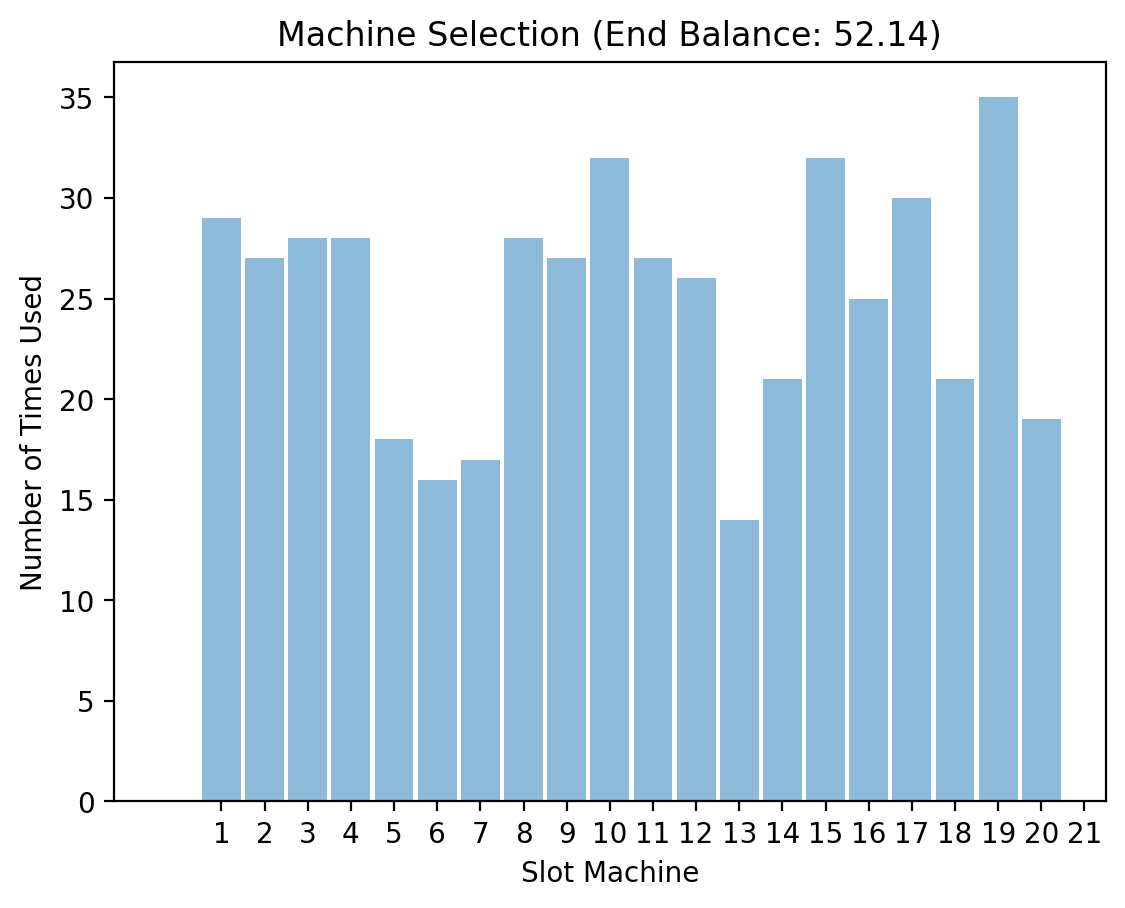

In [10]:
plt.hist(machine_record,bins=range(22),rwidth=0.9, alpha=0.5,align='left')
plt.title("Machine Selection (End Balance: "+ str(round(balance,2))+")")
plt.xlabel("Slot Machine")
plt.ylabel("Number of Times Used")
plt.xticks(np.arange(1,22,1))
plt.show()

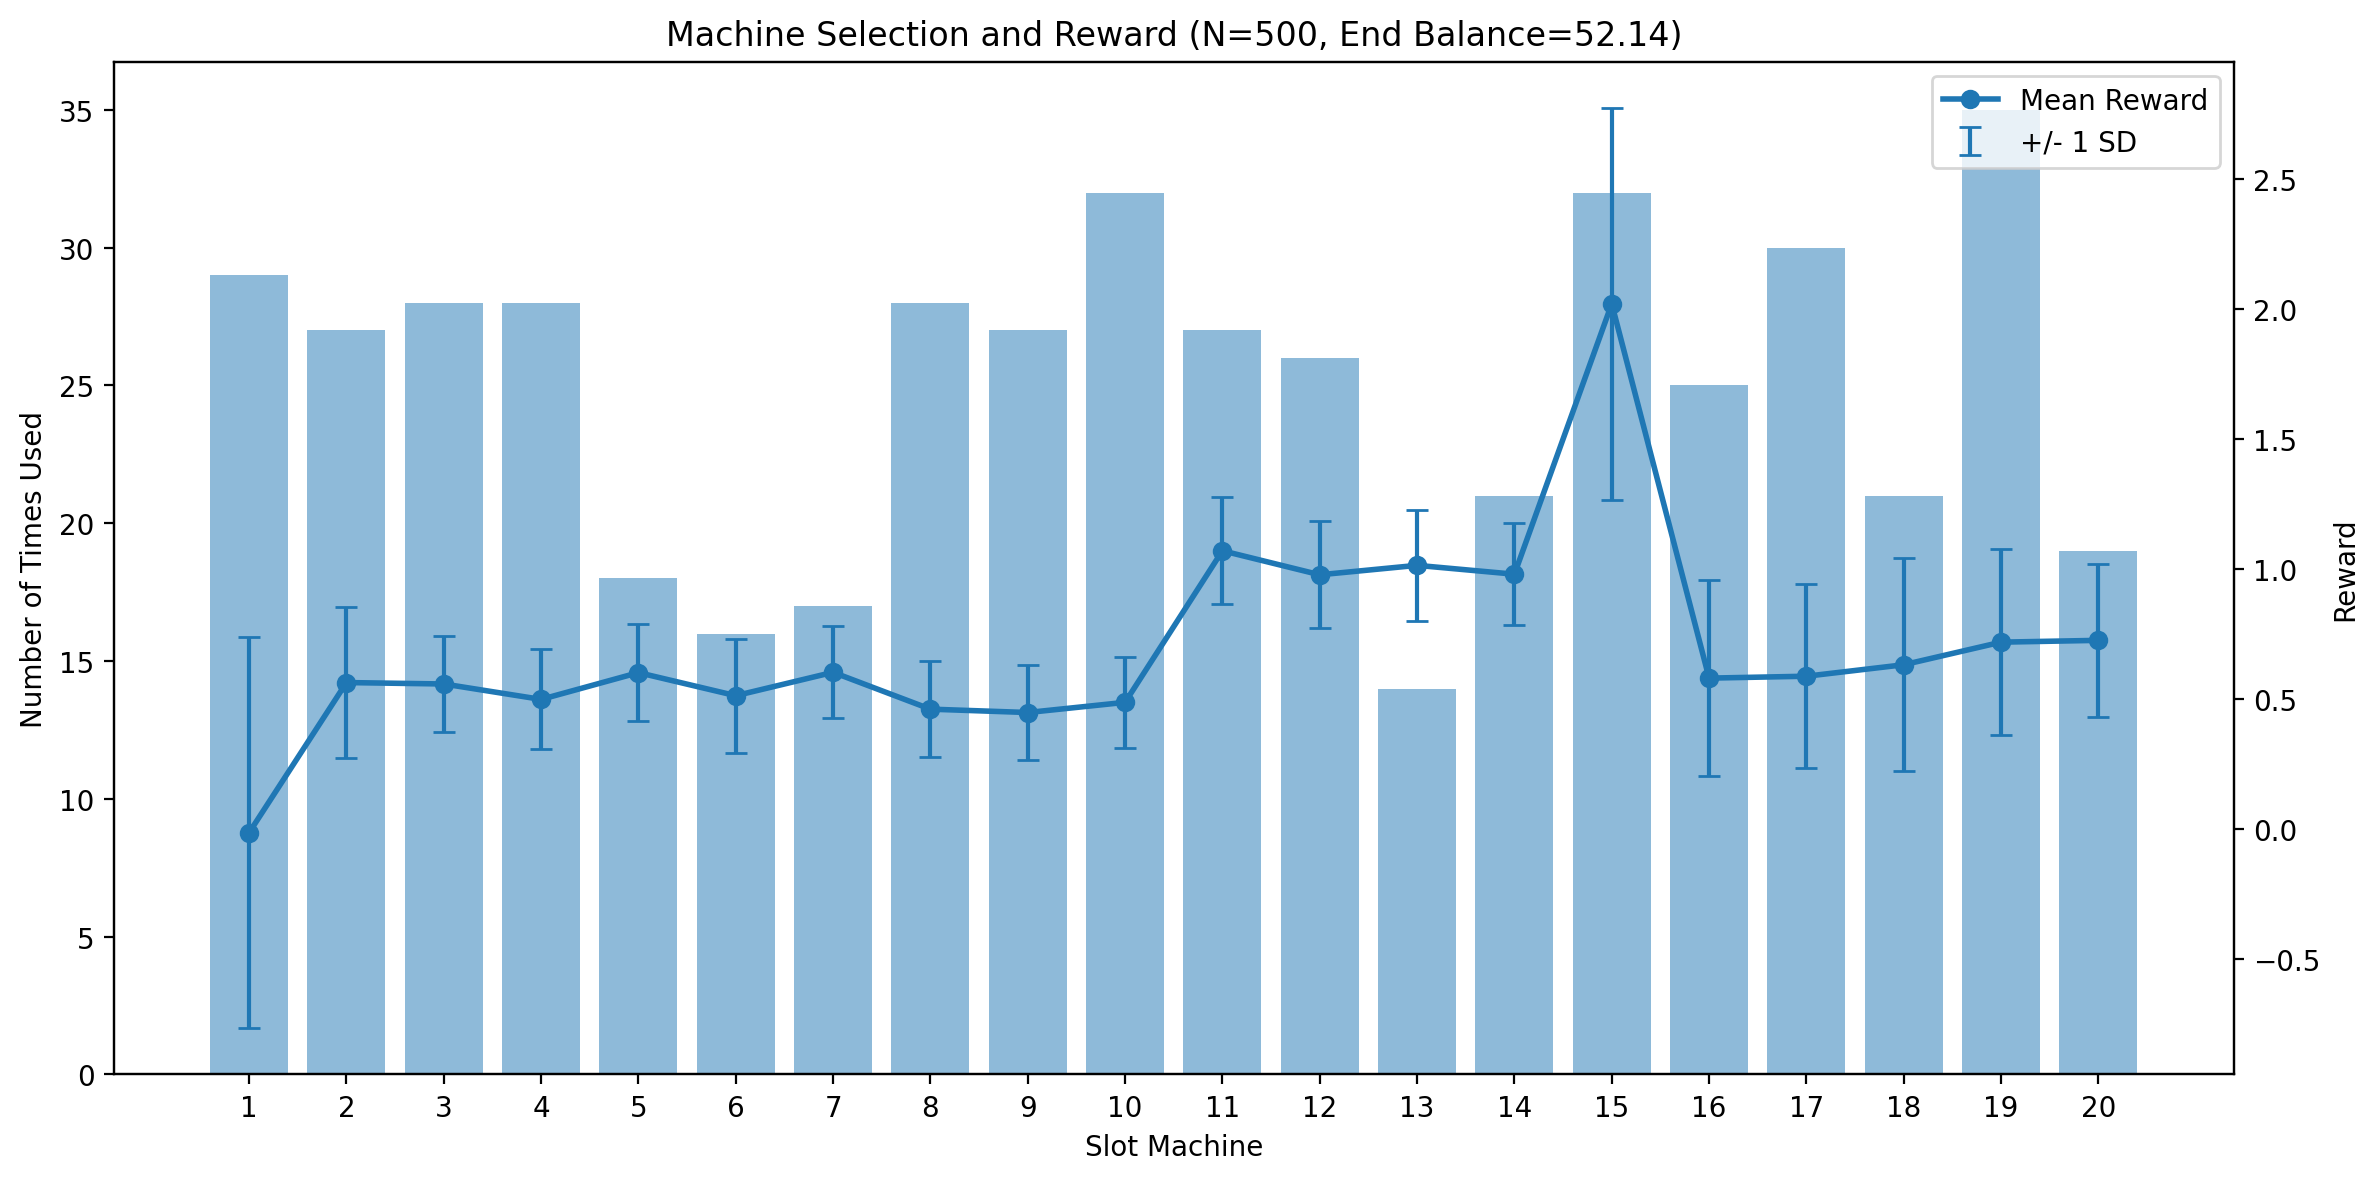

In [11]:
machines = np.arange(1, d + 1)

machine_record_arr = np.asarray(machine_record)
award_record_arr = np.asarray(award_record)

# --------------------------------
# Compute statistics for each arm
# --------------------------------
counts = np.array([
    np.sum(machine_record_arr == m)
    for m in machines
])

means = np.array([
    np.mean(award_record_arr[machine_record_arr == m])
    if np.sum(machine_record_arr == m) > 0 else np.nan
    for m in machines
])

stds = np.array([
    np.std(
        award_record_arr[machine_record_arr == m],
        ddof=1
    )
    if np.sum(machine_record_arr == m) > 1 else 0
    for m in machines
])

# --------------------------------
# Plot
# --------------------------------
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bars: number of times each machine was selected
ax1.bar(
    machines,
    counts,
    alpha=0.5,
    width=0.8
)

ax1.set_xlabel("Slot Machine")
ax1.set_ylabel("Number of Times Used")
ax1.set_xticks(machines)

# Second y-axis for reward
ax2 = ax1.twinx()

# Mean reward curve
ax2.plot(
    machines,
    means,
    marker='o',
    linewidth=2,
    label="Mean Reward"
)

# +/- 1 standard deviation
ax2.errorbar(
    machines,
    means,
    yerr=stds,
    fmt='none',
    capsize=4,
    label="+/- 1 SD"
)

ax2.set_ylabel("Reward")

# Title
plt.title(
    f"Machine Selection and Reward "
    f"(N={N}, End Balance={balance:.2f})"
)

ax2.legend(loc="upper right")

plt.tight_layout()
plt.show()

## Implementation of the UCB algorithm

#### Computational Diagram

<figure>
<center>
<img src='https://i.imgur.com/gAbjrAr.png'width='300px'/>
<figcaption></figcaption></center>
</figure>

In [12]:
# we need tracker variables
# avoid to write numerical values for them in code lines
money = 200
cost = 1
c = 2 # uncertainty constant
d = 20 # the number of different actions we have
n = np.zeros(d) # the number of times we played each action
R = np.zeros(d) # the total rewards we received
max_number_of_plays = 200 # the maximum number of plays
k = 1 # the counter for the number of plays
# we need a tracker for the UCBs as well
UCB = np.zeros(d)
machine_record = []
rewards = []

In [13]:
# now we have to code the actual experiments and updates of the policy
# first we play all the machines once
for i in range(d):
    n[i] = n[i] + 1
    reward = Casino2(i+1)
    R[i] = R[i] + reward
    money = money - cost + reward
    k = 2
    machine_record.append(i+1)
    UCB[i] = R[i]/n[i]+c*np.sqrt(np.log(k)/n[i])

In [14]:
print(UCB)

[2.73510922 1.89510922 2.40510922 2.07510922 2.43510922 2.13510922
 2.18510922 2.34510922 2.02510922 2.30510922 2.76510922 2.54510922
 2.88510922 2.32510922 1.68510922 2.55510922 2.65510922 2.14510922
 2.80510922 2.81510922]


In [15]:
while (money > cost) & (k < max_number_of_plays):
    # label the action with the highest UCB so far
    star = np.argmax(UCB)
    machine_record.append(star+1)
    n[star] = n[star] + 1
    k += 1
    reward = Casino2(star+1) # sampling a reward from machine i+1
    money = money - cost + reward # this update the money you have
    rewards.append(money/k)
    R[star] = R[star] + reward # update the sum of the rewards
    UCB[star] = R[star]/n[star] +c*np.sqrt(np.log(k)/n[star]) # update the UCBs

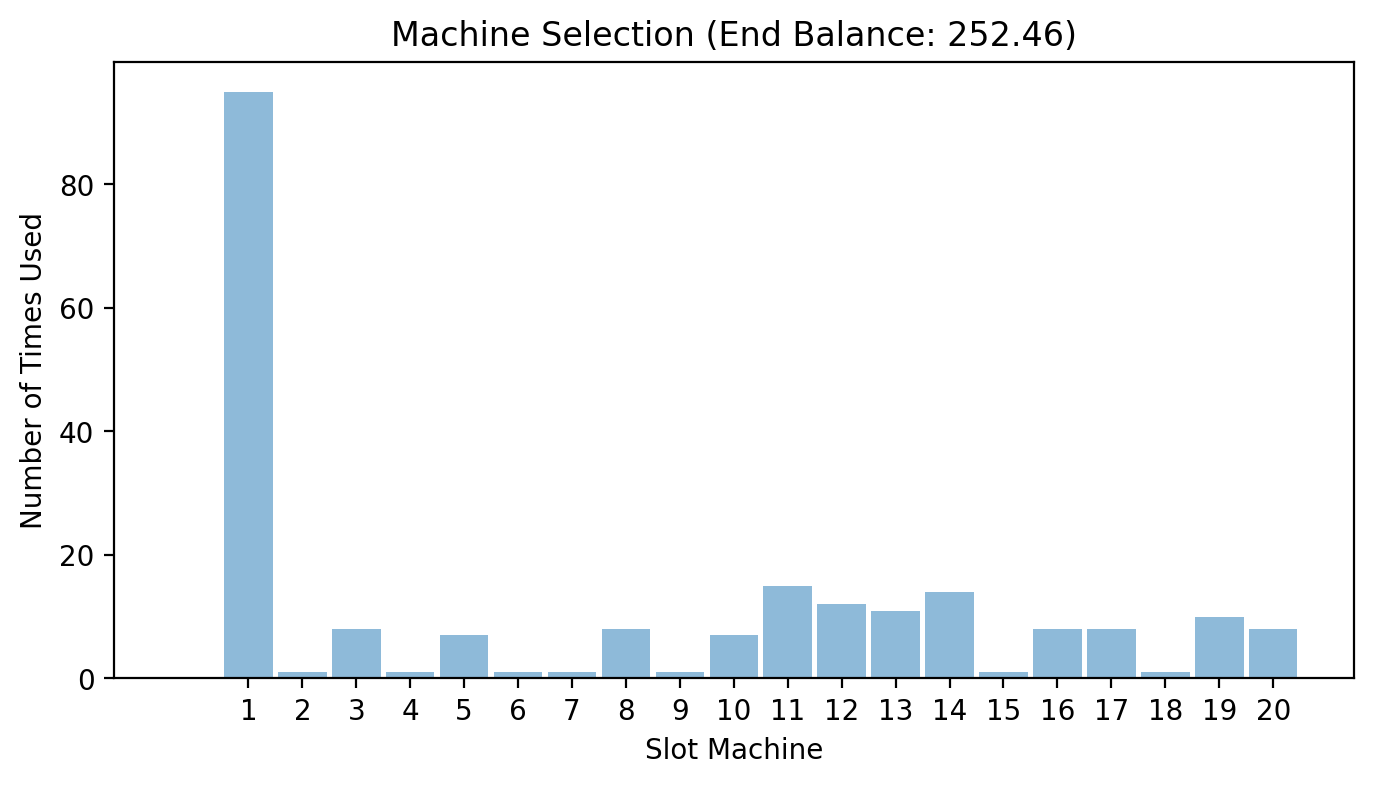

In [16]:
plt.figure(figsize=(8,4))
plt.hist(machine_record,bins=range(22),rwidth=0.9, alpha=0.5,align='left')
plt.title("Machine Selection (End Balance: "+ str(round(money,2))+")")
plt.xlabel("Slot Machine")
plt.ylabel("Number of Times Used")
plt.xticks(np.arange(1,21,1))
plt.show()

## Visualize the Observed Distributions of Rewards

Here we show how to generate violin plots: combining ideas from a box plot and a density plot. The wider the violin at a particular value, the more observations are concentrated around that value.

In [17]:
pos = []
for i in range(20):
    pos.append(i+1)
def sample_casino(i):
    sample = []
    for j in range(1000):
        sample.append(Casino(i+1))
    return sample

In [18]:
pos = range(1,21)

In [19]:
list(pos)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]

In [20]:
dat = [sample_casino(i) for i in range(20)]

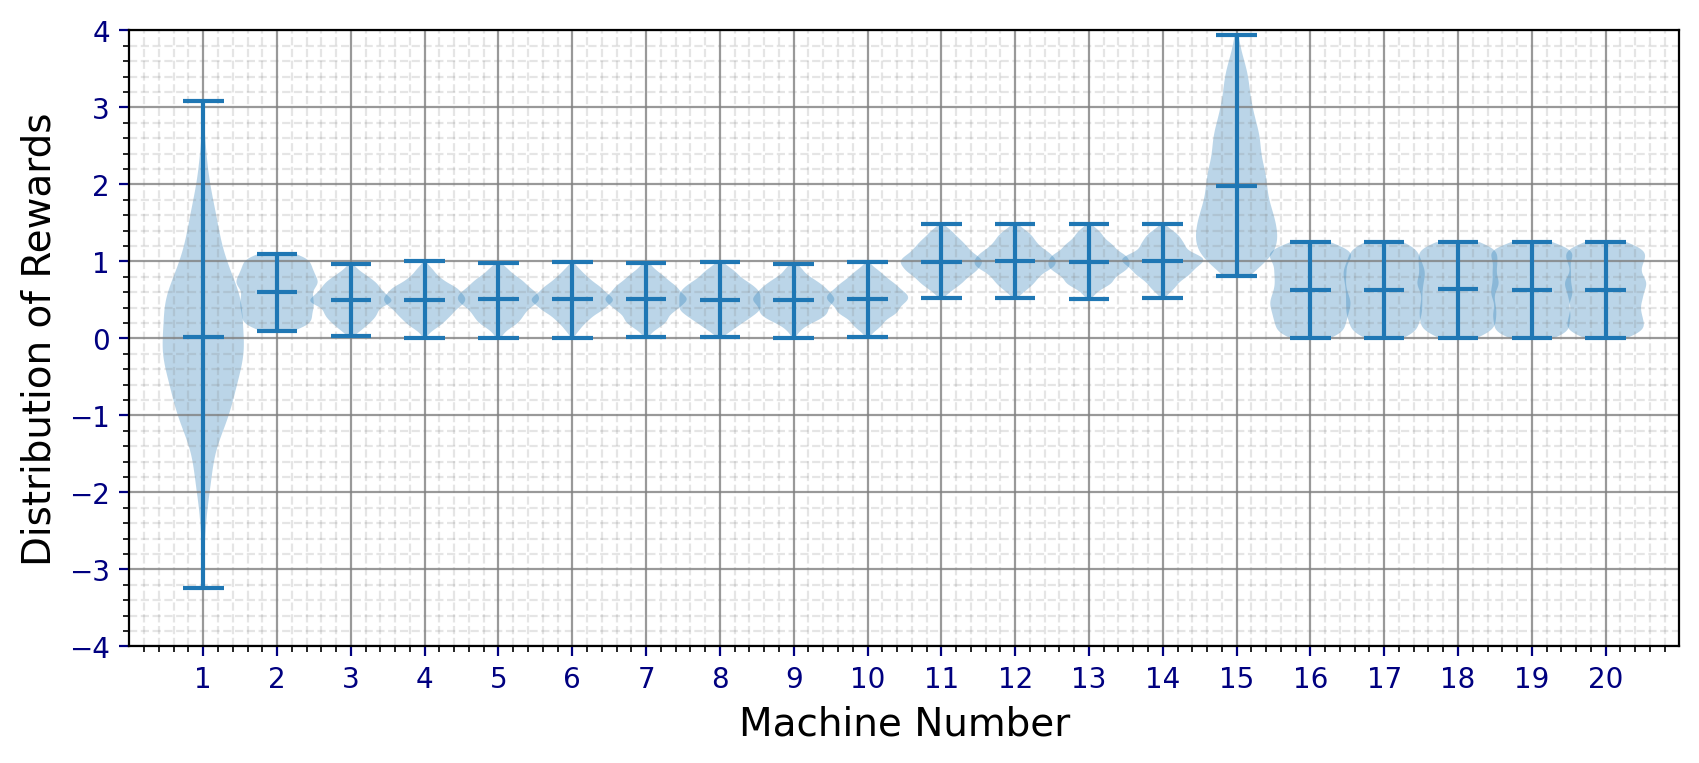

In [21]:
from matplotlib.ticker import MaxNLocator

plt.figure(figsize=(10,4))
plt.violinplot(dat, pos, points=200,vert=True, widths=1.1,
                     showmeans=True, showextrema=True, showmedians=False)
plt.xlim(0, 21)
plt.ylim(-4, 4)
plt.gca().xaxis.set_major_locator(MaxNLocator(prune='both',nbins=21))
plt.xlabel('Machine Number',fontsize=14)
plt.tick_params(axis='x', colors='navy')
plt.tick_params(axis='y', colors='navy')
plt.ylabel('Distribution of Rewards',fontsize=14)
plt.grid(which='major', color ='grey', linestyle='-', alpha=0.8)
plt.grid(which='minor', color ='grey', linestyle='--', alpha=0.2)
plt.minorticks_on()
plt.show()